In [23]:
"Кітапханаларды жүктеу"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [24]:
# Деректерді жүктеу
df = pd.read_csv("student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [25]:
"Бастапқы талдау (міндетті)"
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


МАҚСАТТЫ АЙНЫМАЛЫ ЖАСАУ

In [26]:
df['passed'] = np.where(df['G3'] >= 10, 1, 0)
"Тексеру:"
df['passed'].value_counts()


,count
passed,
1,265
0,130


EDA (СИПАТТАМАЛЫҚ ТАЛДАУ)

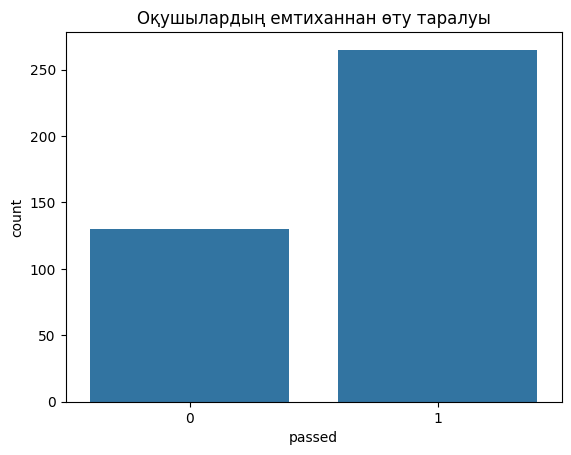

In [27]:
"Мақсатты айнымалының таралуы"
sns.countplot(x='passed', data=df)
plt.title("Оқушылардың емтиханнан өту таралуы")
plt.show()


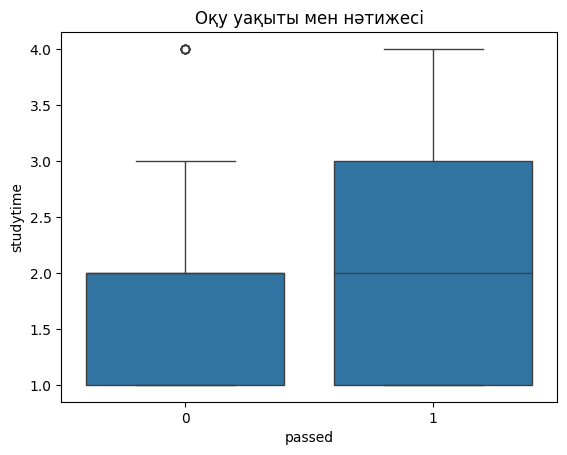

In [28]:
"Оқу уақыты мен баға"
sns.boxplot(x='passed', y='studytime', data=df)
plt.title("Оқу уақыты мен нәтижесі")
plt.show()


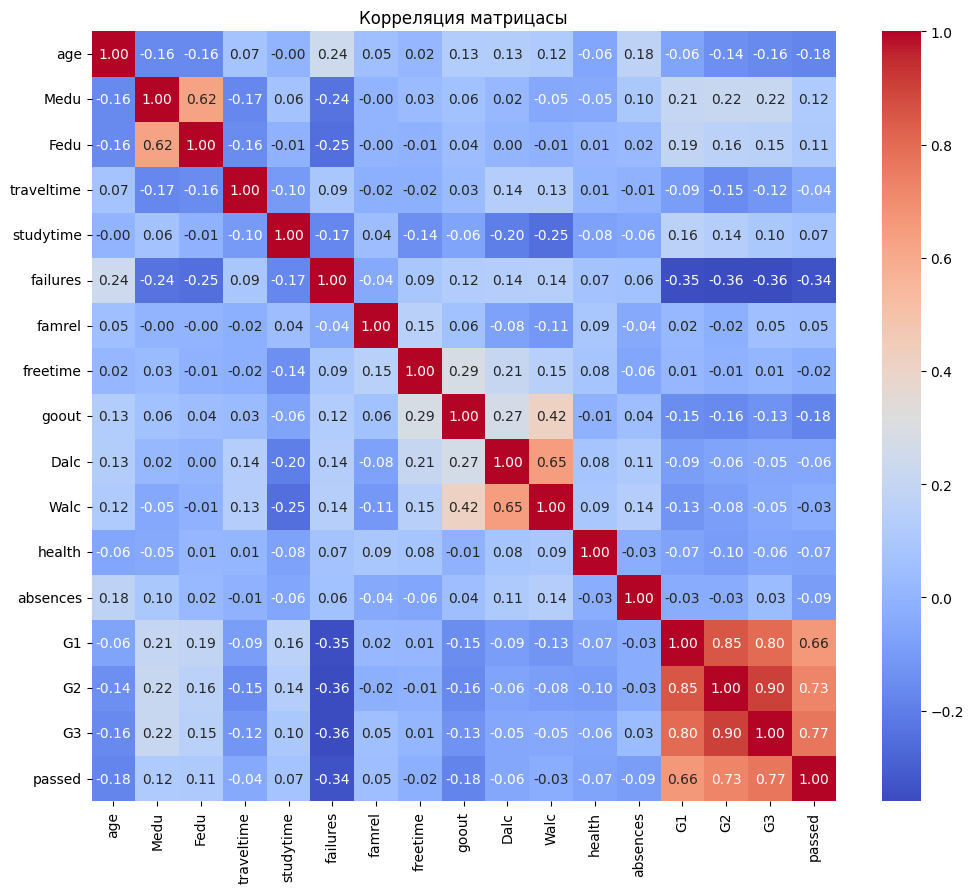

In [29]:
"Корреляция матрицасы"
plt.figure(figsize=(12,10)) # Adjust figure size for better readability
numeric_df = df.select_dtypes(include=np.number) # Select only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm') # Add annotations for clarity
plt.title("Корреляция матрицасы")
plt.show()

ДЕРЕКТЕРДІ АЛДЫН АЛА ӨҢДЕУ (PREPROCESSING)

In [30]:
"Қажетсіз бағандарды алып тастау"
"Біз G3-ті target ретінде қолдандық, сондықтан оны feature ретінде қолданбаймыз."
X = df.drop(['G3', 'passed'], axis=1)
y = df['passed']
"Категориялық бағандарды кодтау"


X = pd.get_dummies(X, drop_first=True)

X.head()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [31]:
"Train / Test бөлу"
"Модельді әділ бағалау үшін деректерді оқыту және тестілеу жиынтығына бөлдік"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [32]:
"StandardScaler қолдану"
"белгілердің масштабын теңестіреді"
"Logistic Regression сияқты модельдер үшін өте маңызды"

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



BASELINE МОДЕЛЬ
Ең қарапайым модель, онымен басқа модельдерді салыстырамыз.

In [24]:
"Logistic Regression үйрету"
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

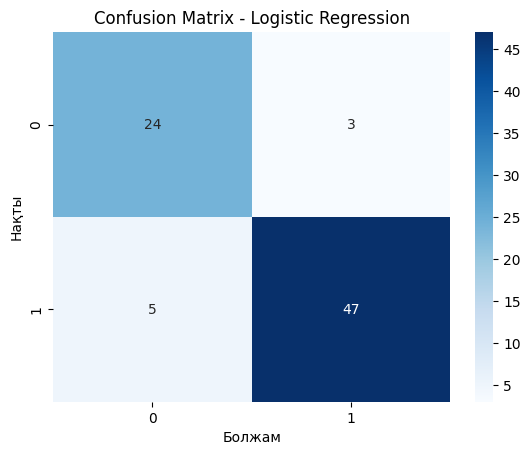

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        27
           1       0.94      0.90      0.92        52

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.90      0.90      0.90        79



In [25]:
"Болжау және бағалау"
y_pred_base = baseline_model.predict(X_test_scaled)

accuracy_base = accuracy_score(y_test, y_pred_base)
accuracy_base
"Confusion Matrix:"
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Болжам")
plt.ylabel("Нақты")
plt.show()

"Classification Report:"
print(classification_report(y_test, y_pred_base))



DECISION TREE МОДЕЛІ:
Модельді үйрету:
Decision Tree масштабтауды талап етпейді, бірақ салыстыру әділ болу үшін сол деректерді қолданамыз.

In [33]:
# Decision Tree моделі (масштабтау қажет емес)
dt_model = DecisionTreeClassifier(random_state=42)

# X already One-Hot encoded above via pd.get_dummies, сондықтан X_train/X_test жеткілікті
dt_model.fit(X_train, y_train)

# Бағалау
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_dt

0.8860759493670886

RANDOM FOREST МОДЕЛІ

In [34]:
# Random Forest моделі (масштабтау қажет емес)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# X already One-Hot encoded above via pd.get_dummies
rf_model.fit(X_train, y_train)

# Бағалау
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_rf
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.96      0.90        27
           1       0.98      0.90      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.93        79



МОДЕЛЬДЕРДІ САЛЫСТЫРУ

In [27]:
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_base, accuracy_dt, accuracy_rf]
})

results


,Модель,Accuracy
0,Logistic Regression,0.898734
1,Decision Tree,0.886076
2,Random Forest,0.924051


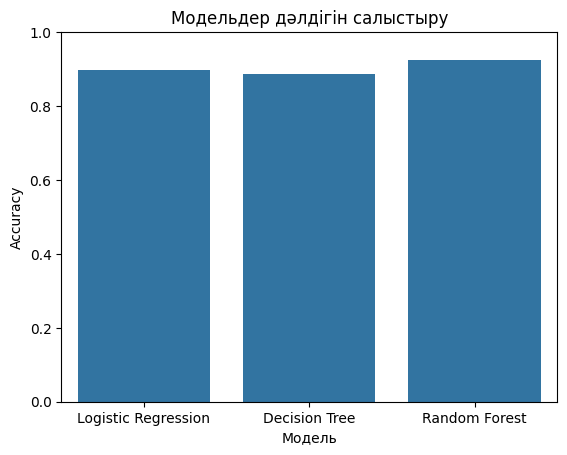

In [19]:
"График:"
sns.barplot(x='Модель', y='Accuracy', data=results)
plt.title("Модельдер дәлдігін салыстыру")
plt.ylim(0,1)
plt.show()


Қорытынды:
Бұл жобада оқушылардың үлгерімін болжау үшін бірнеше Machine Learning модельдері қолданылды.
Алдын ала өңдеу кезеңінде деректер тазаланып, категориялық айнымалылар кодталды және масштабталды.
Нәтижелер бойынша Random Forest моделі ең жоғары дәлдік көрсетті.
Бұл модель күрделі байланыстарды жақсы үйрене алатындықтан, оқу үлгерімін болжау үшін тиімді екені анықталды.